# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [2]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [3]:
# Add as many cells as you need
df = pd.read_csv("zillow_cleaned.csv")
df.head


<bound method NDFrame.head of        bathroomcnt  bedroomcnt  buildingqualitytypeid  calculatedbathnbr  \
0              3.5         4.0                    6.0                3.5   
1              1.0         2.0                    6.0                1.0   
2              2.0         3.0                    6.0                2.0   
3              3.0         4.0                    8.0                3.0   
4              3.0         3.0                    8.0                3.0   
...            ...         ...                    ...                ...   
77104          3.0         3.0                    8.0                3.0   
77105          2.0         2.0                    6.0                2.0   
77106          2.0         4.0                    6.0                2.0   
77107          1.0         3.0                    4.0                1.0   
77108          2.0         3.0                    6.0                2.0   

       calculatedfinishedsquarefeet  finishedsquarefeet12

In [6]:
df.columns

Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedbathnbr', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid',
       'latitude', 'longitude', 'lotsizesquarefeet', 'propertylandusetypeid',
       'regionidcity', 'regionidcounty', 'regionidzip', 'roomcnt', 'unitcnt',
       'yearbuilt', 'taxvaluedollarcnt'],
      dtype='str')

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [8]:
# Add as many cells as you need

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

X = df.drop("taxvaluedollarcnt", axis=1)
y = df["taxvaluedollarcnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

repeated_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_state)

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(
        criterion='absolute_error',
        splitter='best',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features=None,
        random_state=random_state,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0),

    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=random_state)}

results = []

for model_name, model in models.items():
    mae_scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=repeated_cv,
        n_jobs=-1)

    mae_scores = -mae_scores  # convert to positive MAE

    results.append({
        "Model": model_name,
        "Mean CV MAE": mae_scores.mean(),
        "Std CV MAE": mae_scores.std()})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Mean CV MAE").reset_index(drop=True)

print(results_df)

                         Model    Mean CV MAE   Std CV MAE
0  Gradient Boosting Regressor  178997.574746  1819.423681
1            Linear Regression  206517.083799  1722.920128
2      Decision Tree Regressor  231436.565416  3183.677714


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

Models seemed to work well.   The average error ranged from 180k-230k with st dev ranging form 2-3k.  these make sense for errors on housing prices and will go down once we introduce feature engineering and tune the hyperparameters.  it also makes sense as the target variable is highly right skewed due to luxury homes or what not.  these large homes are also contributing to the high average error.   perhaps we should try log scaling the target variable (see log scaled target histogram below)?

Gradient Boosting was the best model with the lowest MAE and a relatively low stdev.  this is expected as boosting models are generally the best performing.

Linear regression models was the second runner up and had slighly lower stdev than GB, indicated that this model is very stable.

the decision tree was the worst of the three default models tested.  it had the highest MAE and also the highest stdev (more variance across the 5 repeated k folds we examined).   this makes sense as single decision trees tend to overfit on the training data and to perform poorly compared to boosting/ensemble models.

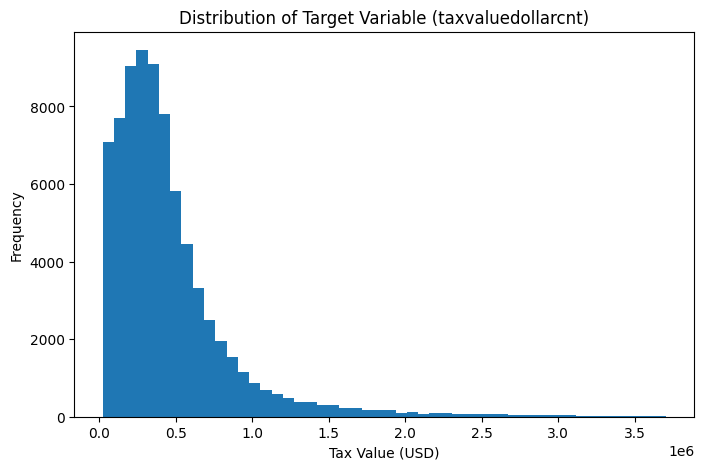

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["taxvaluedollarcnt"], bins=50)
plt.title("Distribution of Target Variable (taxvaluedollarcnt)")
plt.xlabel("Tax Value (USD)")
plt.ylabel("Frequency")
plt.show()

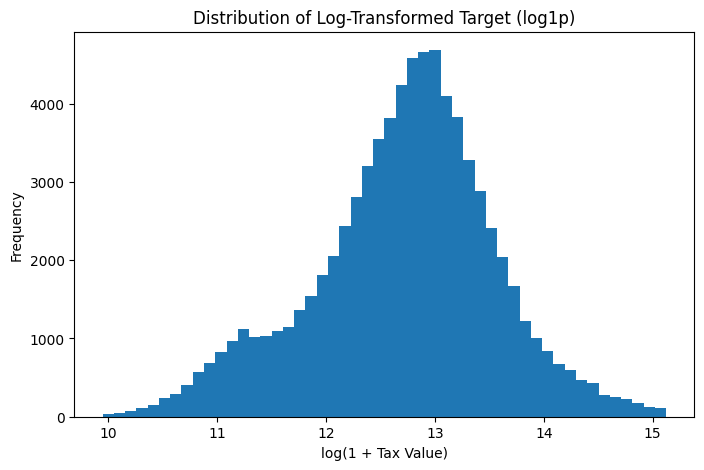

In [ ]:
y_log = np.log1p(y)
plt.figure(figsize=(8, 5))
plt.hist(y_log, bins=50)
plt.title("Distribution of LogTransformed Target (log1p)")
plt.xlabel("log(1 + Tax Value)")
plt.ylabel("Frequency")
plt.show()

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [4]:
# Function to test each feat set

def run_model_cv_test(X,y):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=random_state)

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    repeated_cv = RepeatedKFold(
        n_splits=5,
        n_repeats=5,
        random_state=random_state)

    models = {
        "Linear Regression": LinearRegression(),

        "Decision Tree Regressor": DecisionTreeRegressor(
            criterion='absolute_error',
            splitter='best',
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            min_weight_fraction_leaf=0.0,
            max_features=None,
            random_state=random_state,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.0),

        "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=random_state)}

    results = []

    for model_name, model in models.items():
        mae_scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            scoring="neg_mean_absolute_error",
            cv=repeated_cv,
            n_jobs=-1)

        mae_scores = -mae_scores  # convert to positive MAE

        results.append({
            "Model": model_name,
            "Mean CV MAE": mae_scores.mean(),
            "Std CV MAE": mae_scores.std()})

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="Mean CV MAE").reset_index(drop=True)

    print(results_df)

In [7]:
# Feature set 1
df_1 = df.copy()

df_1['log_sqft'] = np.log1p(df_1['calculatedfinishedsquarefeet'])

X_1 = df_1.drop("taxvaluedollarcnt", axis=1)
y = df["taxvaluedollarcnt"]

run_model_cv_test(X_1,y)


                         Model    Mean CV MAE   Std CV MAE
0  Gradient Boosting Regressor  178994.148962  1819.889338
1            Linear Regression  205330.092972  1785.122317
2      Decision Tree Regressor  231509.609039  3085.479609


In [9]:
# Feature set 2

df_2 = df.copy()

df_2['bath_bed_ratio'] = df['bathroomcnt'] / (df['bedroomcnt'] + 1)

X_2 = df_2.drop("taxvaluedollarcnt", axis=1)
y = df["taxvaluedollarcnt"]

run_model_cv_test(X_2,y)

                         Model    Mean CV MAE   Std CV MAE
0  Gradient Boosting Regressor  179026.649079  1851.954808
1            Linear Regression  206076.137285  1828.192977
2      Decision Tree Regressor  232323.466881  2255.425559


In [10]:
# Feature set 3 

df_3 = df.copy()

df_3['log_lotsize'] = np.log1p(df['lotsizesquarefeet'])

X_3 = df_3.drop("taxvaluedollarcnt", axis=1)
y = df["taxvaluedollarcnt"]

run_model_cv_test(X_3,y)

                         Model    Mean CV MAE   Std CV MAE
0  Gradient Boosting Regressor  178995.940368  1819.366329
1            Linear Regression  206534.835705  1729.001668
2      Decision Tree Regressor  231187.829855  2573.305857


In [11]:
# All new features

df_1['bath_bed_ratio'] = df['bathroomcnt'] / (df['bedroomcnt'] + 1)
df_1['log_lotsize'] = np.log1p(df['lotsizesquarefeet'])

X_all = df_1.drop("taxvaluedollarcnt", axis=1)

run_model_cv_test(X_all,y)


                         Model    Mean CV MAE   Std CV MAE
0  Gradient Boosting Regressor  179024.752935  1855.003431
1            Linear Regression  205210.246255  1849.391952
2      Decision Tree Regressor  231975.576514  2145.693475


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




> All of the models showed about the same MAE with only minor adjustment but nothing substantial. 

> The feature that helped add the most improvement was the 'log_sqft' feature which had the highest corr when ran in Mile Stone 1. It mostly only improved the Linear Regression

> Our best guess for the reason only one of these features helped is becuase it was the only feature with a decently high correlation. Since Linear regression does not deal with the same decesion making process on feature like splitting and having depth we think this is the reason why it affected this overall model most though not a significant amount.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [5]:
# Add as many cells as you need


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


> Your text here

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [6]:
# Add as many cells as you need


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


> Your text here

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [7]:
# Add as many cells as you need


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here